# Análisis de entrenamientos iterativos (Baselines + DistilBERT)

Este notebook consolida y compara resultados de entrenamientos iterativos para:
- **Baselines**: Doc2Vec y FastText en RAW / PREPRO / PREPRO+NGRAM (10 iteraciones).
- **DistilBERT**: FE, PFT, FFT y FFT11 (5 iteraciones).

Se analizan métricas **top-1 a top-5**, curvas de entrenamiento/validación y comparaciones entre familias de modelos.

In [1]:

import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
pd.set_option('display.max_columns', 200)


## 1) Carga y normalización de resultados

In [2]:

BASE_DIR = Path('results')
BASELINES_DIR = BASE_DIR / 'baselines'
DISTILBERT_DIR = BASE_DIR / 'distilbert'

assert BASELINES_DIR.exists(), f"No existe {BASELINES_DIR}"
assert DISTILBERT_DIR.exists(), f"No existe {DISTILBERT_DIR}"

baseline_files = sorted(BASELINES_DIR.glob('*.csv'))
baseline_files


[PosixPath('results/baselines/scored_dfs_D2V_GOODS_DESCRIPTION_HS04_seed503070489.csv'),
 PosixPath('results/baselines/scored_dfs_D2V_PREPRO_DESCRIPTION_HS04_seed503070489.csv'),
 PosixPath('results/baselines/scored_dfs_D2V_PREPRO_DESCRIPTION_NGRAM_DESCRIPTION_HS04_seed503070489.csv'),
 PosixPath('results/baselines/scored_dfs_FT_GOODS_DESCRIPTION_HS04_seed503070489.csv'),
 PosixPath('results/baselines/scored_dfs_FT_PREPRO_DESCRIPTION_HS04_seed503070489.csv'),
 PosixPath('results/baselines/scored_dfs_FT_PREPRO_DESCRIPTION_NGRAM_DESCRIPTION_HS04_seed503070489.csv')]

In [3]:

def parse_baseline_filename(path: Path):
    name = path.stem
    # scored_dfs_<MODEL>_<TEXTCOL>_HS04_seed...
    payload = name.replace('scored_dfs_', '')
    if payload.startswith('D2V_'):
        model = 'D2V'
        rest = payload[len('D2V_'):]
    elif payload.startswith('FT_'):
        model = 'FT'
        rest = payload[len('FT_'):]
    else:
        model = 'UNKNOWN'
        rest = payload

    # remover sufijo _HS04_seed...
    rest = re.sub(r'_HS04_seed\d+$', '', rest)

    text_type = {
        'GOODS_DESCRIPTION': 'RAW',
        'PREPRO_DESCRIPTION': 'PREPRO',
        'PREPRO_DESCRIPTION_NGRAM_DESCRIPTION': 'PREPRO+NGRAM'
    }.get(rest, rest)
    return model, text_type

baseline_rows = []
for f in baseline_files:
    model, text_type = parse_baseline_filename(f)
    df = pd.read_csv(f).copy()
    df['iteration'] = np.arange(1, len(df)+1)
    df['model'] = model
    df['text_type'] = text_type
    df['family'] = df['model'] + '_' + df['text_type']
    baseline_rows.append(df)

baseline_long = pd.concat(baseline_rows, ignore_index=True)
baseline_long.head()


,top_1_acc,top_2_acc,top_3_acc,top_4_acc,top_5_acc,iteration,model,text_type,family
0,0.519083,0.613339,0.654791,0.682127,0.700799,1,D2V,RAW,D2V_RAW
1,0.514228,0.604825,0.649563,0.678393,0.697662,2,D2V,RAW,D2V_RAW
2,0.513033,0.605945,0.647920,0.675704,0.694675,3,D2V,RAW,D2V_RAW
3,0.510643,0.604601,0.650235,0.677496,0.695422,4,D2V,RAW,D2V_RAW
4,0.510120,0.600269,0.646202,0.671073,0.689447,5,D2V,RAW,D2V_RAW


In [4]:

metrics_files = {
    'fe': DISTILBERT_DIR / 'fe' / 'metrics_fe_GOODS_DESCRIPTION_HS04.csv',
    'pft': DISTILBERT_DIR / 'pft' / 'metrics_pft_GOODS_DESCRIPTION_HS04.csv',
    'fft': DISTILBERT_DIR / 'fft' / 'metrics_fft_GOODS_DESCRIPTION_HS04.csv',
    'fft11': DISTILBERT_DIR / 'fft11' / 'experiments_job_fft_v11_metrics_fft_GOODS_DESCRIPTION_HS04.csv',
}
history_files = {
    'fe': DISTILBERT_DIR / 'fe' / 'history_all_iters_fe.csv',
    'pft': DISTILBERT_DIR / 'pft' / 'history_all_iters_pft.csv',
    'fft': DISTILBERT_DIR / 'fft' / 'history_all_iters_fft.csv',
    'fft11': DISTILBERT_DIR / 'fft11' / 'experiments_job_fft_v11_history_all_iters_fft.csv',
}

for k, v in {**metrics_files, **history_files}.items():
    assert v.exists(), f"Falta archivo de {k}: {v}"

dist_metrics = []
for train_type, f in metrics_files.items():
    df = pd.read_csv(f).copy()
    df['train_type'] = train_type.upper()
    df['iteration'] = np.arange(1, len(df)+1)
    dist_metrics.append(df)

dist_metrics = pd.concat(dist_metrics, ignore_index=True)
dist_metrics.head()


,model,top_1_acc,top_2_acc,top_3_acc,top_4_acc,top_5_acc,train_type,iteration
0,DBERT_fe_GOODS_DESCRIPTION_HS04_seed31187689,0.523863,0.625439,0.676301,0.710583,0.736351,FE,1
1,DBERT_fe_GOODS_DESCRIPTION_HS04_seed491185480,0.525655,0.629845,0.679812,0.709239,0.732542,FE,2
2,DBERT_fe_GOODS_DESCRIPTION_HS04_seed737166323,0.526402,0.627455,0.678617,0.710135,0.735230,FE,3
3,DBERT_fe_GOODS_DESCRIPTION_HS04_seed95156473,0.523415,0.624318,0.673165,0.708716,0.733662,FE,4
4,DBERT_fe_GOODS_DESCRIPTION_HS04_seed954562093,0.534095,0.635895,0.688625,0.723206,0.747479,FE,5


## 2) Performance de baselines

In [5]:

baseline_summary = (
    baseline_long
    .groupby(['model','text_type'])[['top_1_acc','top_2_acc','top_3_acc','top_4_acc','top_5_acc']]
    .agg(['mean','std','min','max'])
    .round(4)
)
baseline_summary


top_1_acc                         top_2_acc          \
                        mean     std     min     max      mean     std   
model text_type                                                          
D2V   PREPRO          0.4745  0.0056  0.4637  0.4836    0.5568  0.0058   
      PREPRO+NGRAM    0.6084  0.0072  0.5959  0.6213    0.6848  0.0065   
      RAW             0.5120  0.0046  0.5015  0.5191    0.6044  0.0056   
FT    PREPRO          0.5766  0.0053  0.5685  0.5864    0.7056  0.0045   
      PREPRO+NGRAM    0.5784  0.0048  0.5714  0.5836    0.7052  0.0046   
      RAW             0.5370  0.0049  0.5307  0.5480    0.6615  0.0048   

                                   top_3_acc                          \
                       min     max      mean     std     min     max   
model text_type                                                        
D2V   PREPRO        0.5440  0.5643    0.5968  0.0051  0.5862  0.6040   
      PREPRO+NGRAM  0.6739  0.6955    0.7149  0.0049  0.7071  0.7238   
      RAW           0.5924  0.6133    0.6486  0.0036  0.6417  0.6548   
FT    PREPRO        0.6998  0.7151    0.7637  0.0042  0.7581  0.7715   
      PREPRO+NGRAM  0.6989  0.7135    0.7628  0.0041  0.7563  0.7701   
      RAW           0.6564  0.6726    0.7188  0.0049  0.7118  0.7305   

                   top_4_acc                         top_5_acc          \
                        mean     std     min     max      mean     std   
model text_type                                                          
D2V   PREPRO          0.6225  0.0051  0.6126  0.6287    0.6409  0.0053   
      PREPRO+NGRAM    0.7315  0.0047  0.7239  0.7397    0.7431  0.0045   
      RAW             0.6752  0.0043  0.6670  0.6821    0.6937  0.0040   
FT    PREPRO          0.7980  0.0041  0.7907  0.8041    0.8205  0.0038   
      PREPRO+NGRAM    0.7965  0.0037  0.7912  0.8035    0.8197  0.0036   
      RAW             0.7537  0.0040  0.7488  0.7631    0.7773  0.0033   

                                    
                       min     max  
model text_type                     
D2V   PREPRO        0.6305  0.6487  
      PREPRO+NGRAM  0.7352  0.7511  
      RAW           0.6877  0.7008  
FT    PREPRO        0.8157  0.8279  
      PREPRO+NGRAM  0.8146  0.8262  
      RAW           0.7731  0.7846

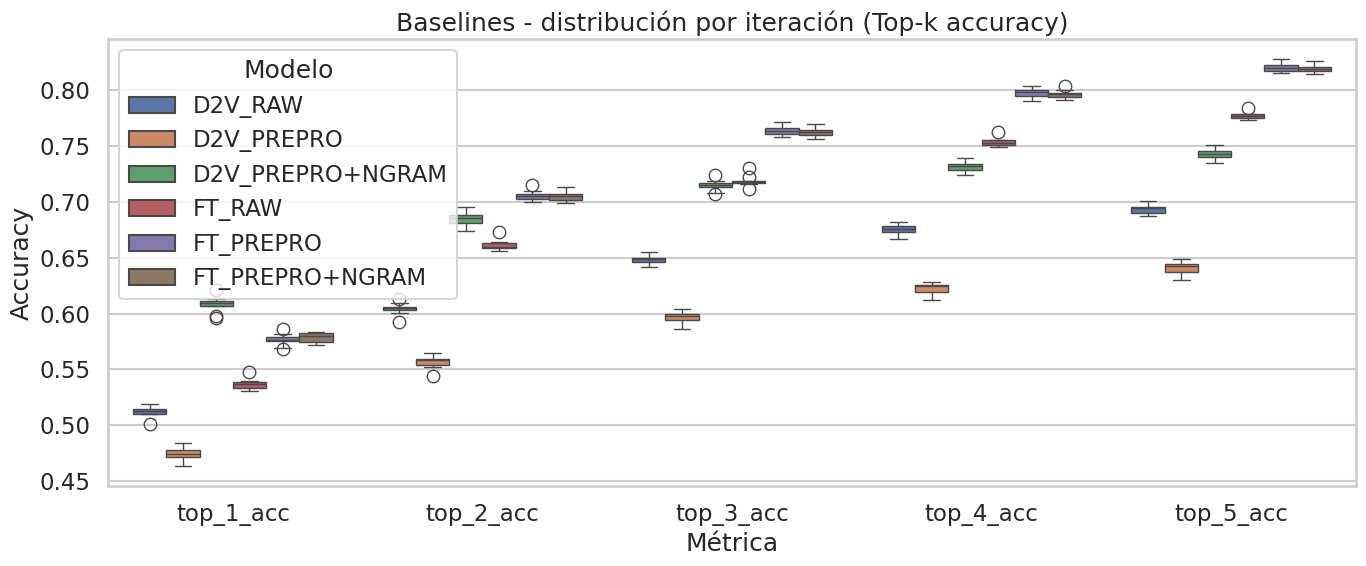

In [6]:

plt.figure(figsize=(14,6))
plot_df = baseline_long.melt(
    id_vars=['iteration','model','text_type','family'],
    value_vars=['top_1_acc','top_2_acc','top_3_acc','top_4_acc','top_5_acc'],
    var_name='top_k',
    value_name='acc'
)
sns.boxplot(data=plot_df, x='top_k', y='acc', hue='family')
plt.title('Baselines - distribución por iteración (Top-k accuracy)')
plt.xlabel('Métrica')
plt.ylabel('Accuracy')
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()


## 3) Performance DistilBERT + curvas de entrenamiento

In [7]:

dist_summary = (
    dist_metrics
    .groupby('train_type')[['top_1_acc','top_2_acc','top_3_acc','top_4_acc','top_5_acc']]
    .agg(['mean','std','min','max'])
    .round(4)
)
dist_summary


top_1_acc                         top_2_acc                  \
                mean     std     min     max      mean     std     min   
train_type                                                               
FE            0.5267  0.0043  0.5234  0.5341    0.6286  0.0046  0.6243   
FFT           0.6627  0.0048  0.6545  0.6658    0.7569  0.0029  0.7536   
FFT11         0.6637  0.0015  0.6623  0.6660    0.7553  0.0020  0.7536   
PFT           0.6507  0.0028  0.6481  0.6552    0.7463  0.0027  0.7434   

                   top_3_acc                         top_4_acc          \
               max      mean     std     min     max      mean     std   
train_type                                                               
FE          0.6359    0.6793  0.0058  0.6732  0.6886    0.7124  0.0061   
FFT         0.7614    0.7977  0.0034  0.7924  0.8016    0.8228  0.0036   
FFT11       0.7579    0.7976  0.0019  0.7946  0.7997    0.8222  0.0017   
PFT         0.7503    0.7901  0.0029  0.7872  0.7939    0.8148  0.0023   

                           top_5_acc                          
               min     max      mean     std     min     max  
train_type                                                    
FE          0.7087  0.7232    0.7371  0.0060  0.7325  0.7475  
FFT         0.8170  0.8259    0.8392  0.0032  0.8343  0.8423  
FFT11       0.8198  0.8241    0.8388  0.0012  0.8374  0.8405  
PFT         0.8122  0.8175    0.8330  0.0020  0.8310  0.8361

In [8]:

history_rows = []
for train_type, f in history_files.items():
    df = pd.read_csv(f).copy()
    df['train_type'] = train_type.upper()
    df['iteration'] = df['iteration'] + 1
    history_rows.append(df)

dist_history = pd.concat(history_rows, ignore_index=True)
dist_history.head()


,iteration,seed,epoch,train_loss,train_acc,train_top1_acc,train_top2_acc,train_top3_acc,train_top4_acc,train_top5_acc,val_loss,val_acc,val_top1_acc,val_top2_acc,val_top3_acc,val_top4_acc,val_top5_acc,train_type
0,1,491185480,1,3.556737,0.334933,0.334933,0.425275,0.476527,0.511922,0.539692,2.716067,0.446785,0.446785,0.547390,0.597655,0.635148,0.661438,FE
1,1,491185480,2,2.819426,0.424199,0.424199,0.526869,0.581612,0.618844,0.646599,2.554040,0.471581,0.471581,0.574352,0.626186,0.661214,0.686235,FE
2,1,491185480,3,2.694364,0.441761,0.441761,0.546139,0.601510,0.638354,0.665857,2.487311,0.478677,0.478677,0.586003,0.638360,0.671820,0.696318,FE
3,1,491185480,4,2.632907,0.450995,0.450995,0.555719,0.611675,0.647902,0.675378,2.452231,0.486743,0.486743,0.591829,0.645903,0.677198,0.702517,FE
4,1,491185480,5,2.590887,0.456527,0.456527,0.562853,0.618342,0.654208,0.681679,2.418344,0.498768,0.498768,0.599746,0.649862,0.680559,0.705280,FE


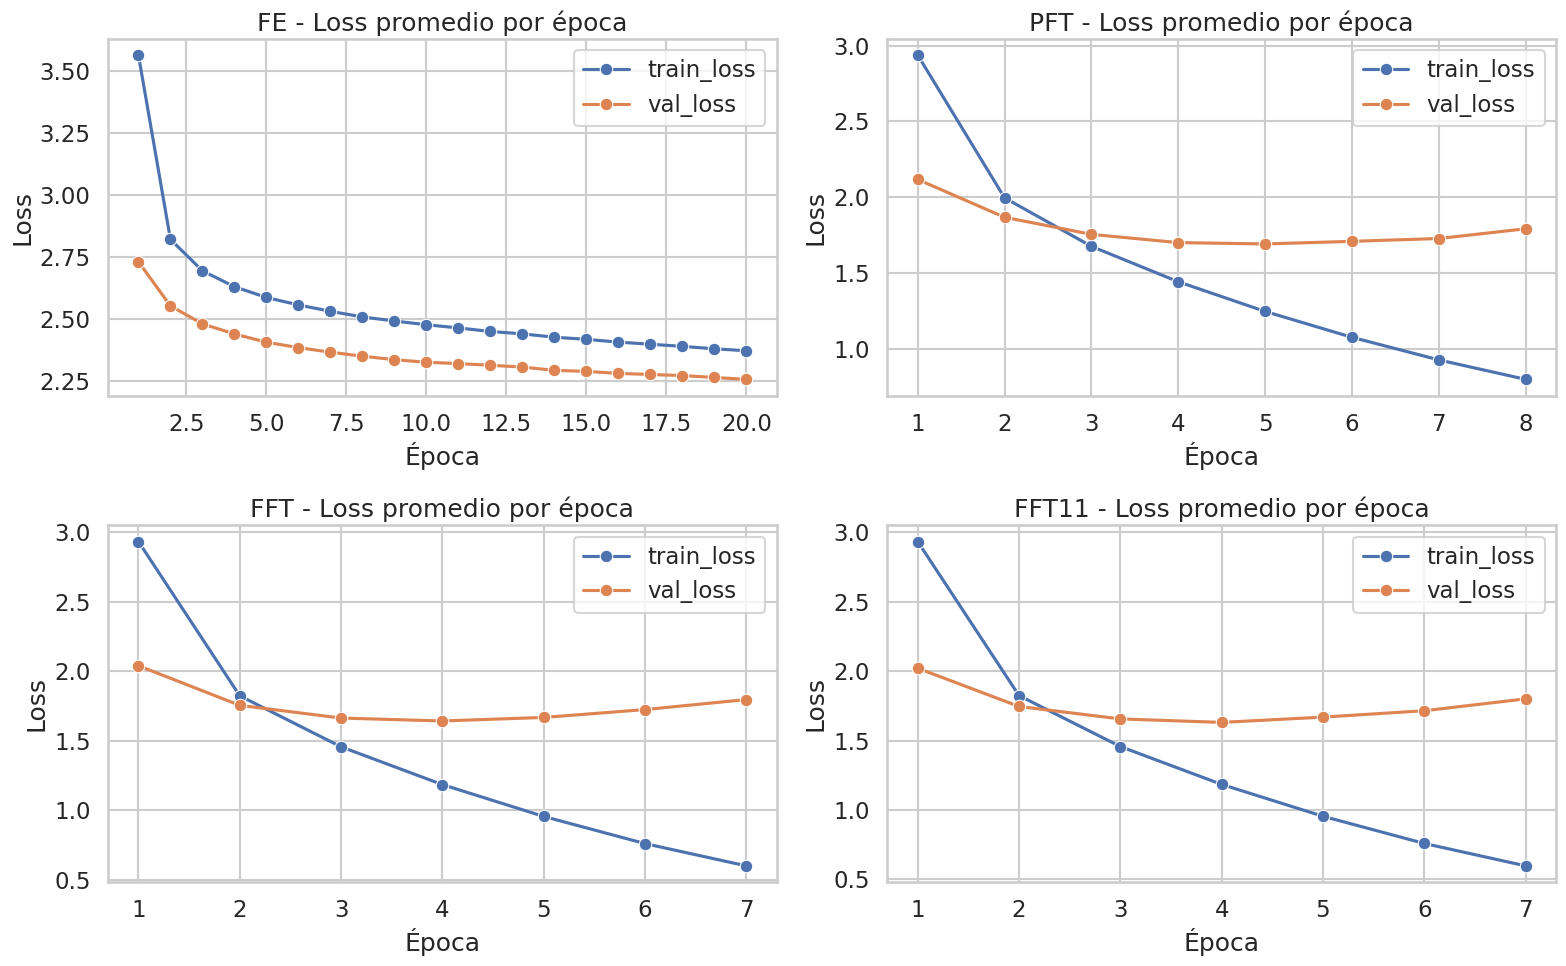

In [9]:

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharex=False)
axes = axes.flatten()
for ax, train_type in zip(axes, ['FE','PFT','FFT','FFT11']):
    df = dist_history[dist_history['train_type']==train_type]
    mean_by_epoch = df.groupby('epoch')[['train_loss','val_loss']].mean().reset_index()
    sns.lineplot(data=mean_by_epoch, x='epoch', y='train_loss', marker='o', label='train_loss', ax=ax)
    sns.lineplot(data=mean_by_epoch, x='epoch', y='val_loss', marker='o', label='val_loss', ax=ax)
    ax.set_title(f'{train_type} - Loss promedio por época')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.show()


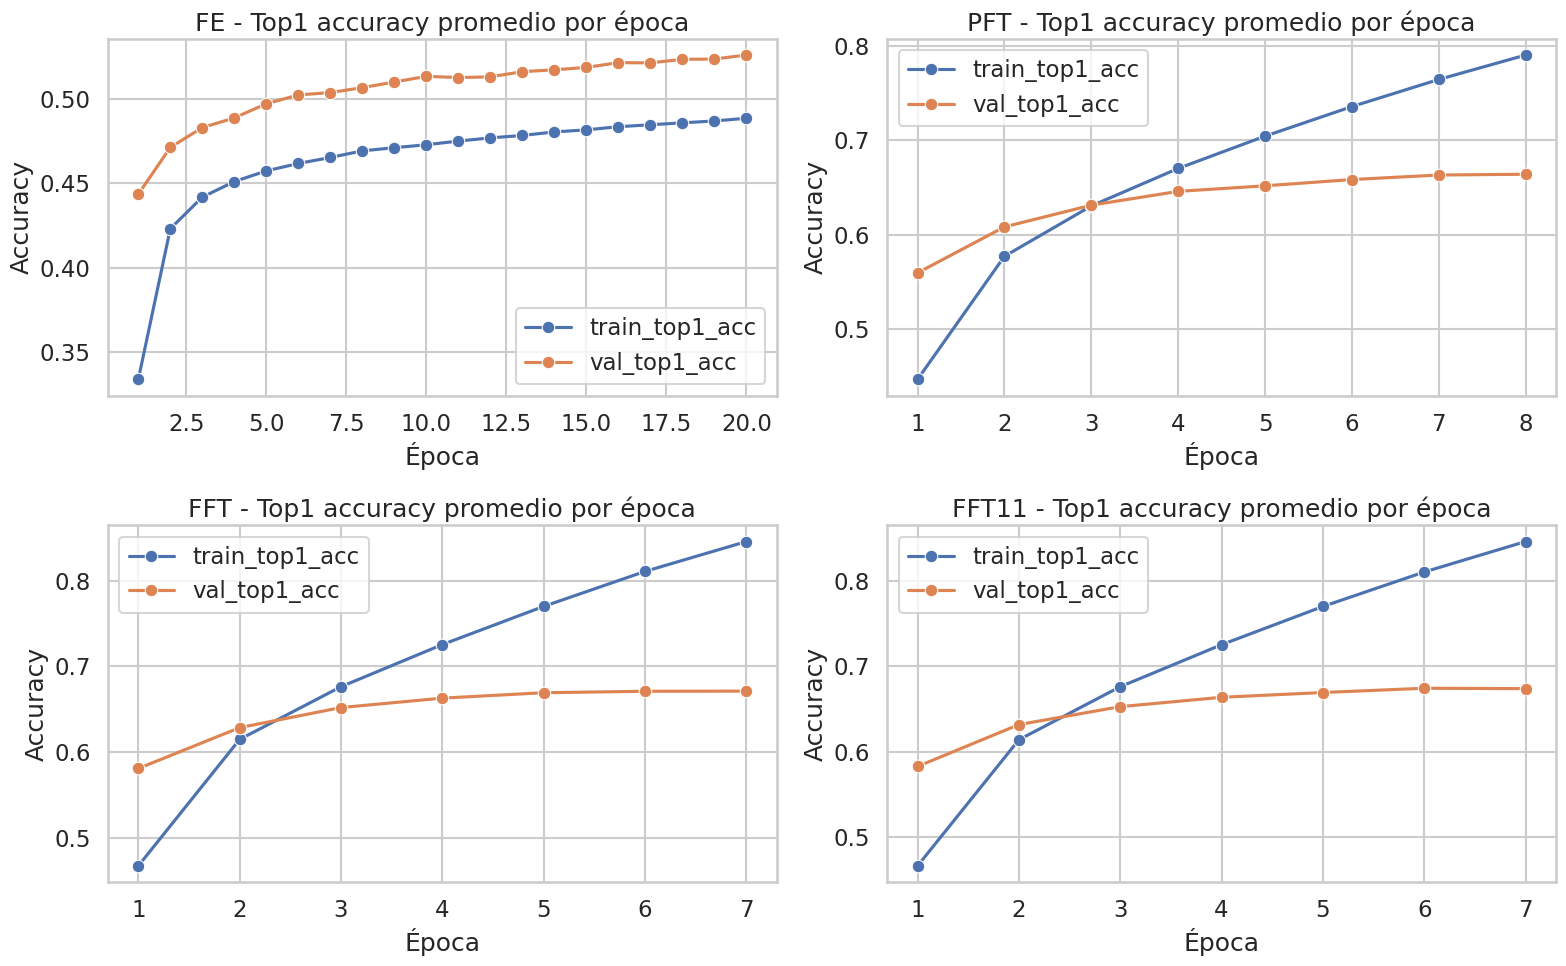

In [10]:

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharex=False)
axes = axes.flatten()
for ax, train_type in zip(axes, ['FE','PFT','FFT','FFT11']):
    df = dist_history[dist_history['train_type']==train_type]
    mean_by_epoch = df.groupby('epoch')[['train_top1_acc','val_top1_acc']].mean().reset_index()
    sns.lineplot(data=mean_by_epoch, x='epoch', y='train_top1_acc', marker='o', label='train_top1_acc', ax=ax)
    sns.lineplot(data=mean_by_epoch, x='epoch', y='val_top1_acc', marker='o', label='val_top1_acc', ax=ax)
    ax.set_title(f'{train_type} - Top1 accuracy promedio por época')
    ax.set_xlabel('Época')
    ax.set_ylabel('Accuracy')
    ax.legend()
plt.tight_layout()
plt.show()


In [11]:

# Época de mejor performance (máximo val_top1_acc) por iteración
best_epochs = (
    dist_history
    .sort_values(['train_type','iteration','val_top1_acc'], ascending=[True,True,False])
    .groupby(['train_type','iteration'], as_index=False)
    .first()[['train_type','iteration','epoch','val_top1_acc','val_loss']]
    .sort_values(['train_type','iteration'])
)
best_epochs


,train_type,iteration,epoch,val_top1_acc,val_loss
0,FE,1,19,0.525655,2.264265
1,FE,2,20,0.534095,2.216730
2,FE,3,18,0.526850,2.258218
3,FE,4,20,0.523863,2.284670
4,FE,5,19,0.524610,2.279328
5,FFT,1,7,0.670102,1.793566
6,FFT,2,6,0.671895,1.707225
7,FFT,3,7,0.669281,1.810255
8,FFT,4,7,0.673389,1.784926
9,FFT,5,6,0.672343,1.720245


## 4) Comparaciones de performance: baselines

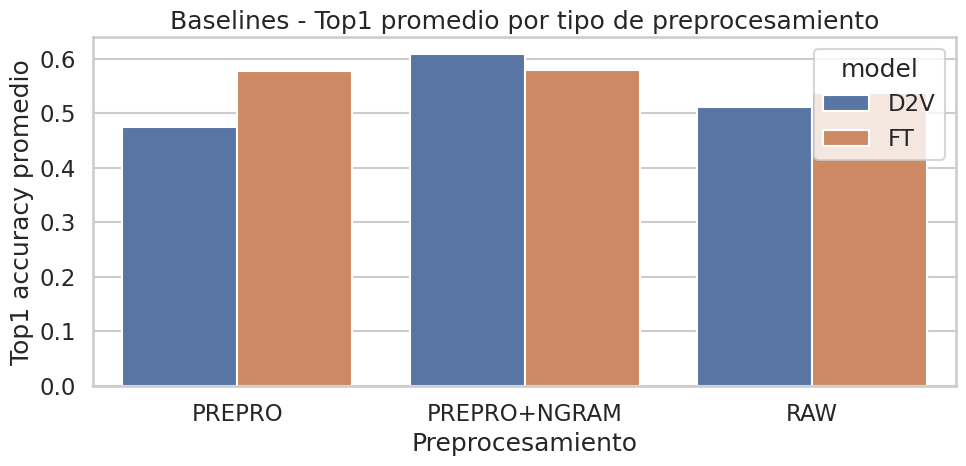

In [12]:

base_top1 = (baseline_long.groupby(['model','text_type'])['top_1_acc'].mean().reset_index())
plt.figure(figsize=(10,5))
sns.barplot(data=base_top1, x='text_type', y='top_1_acc', hue='model')
plt.title('Baselines - Top1 promedio por tipo de preprocesamiento')
plt.xlabel('Preprocesamiento')
plt.ylabel('Top1 accuracy promedio')
plt.tight_layout()
plt.show()


## 5) Comparaciones de performance: DistilBERT

/tmp/ipykernel_5435/2938457762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_top1, x='train_type', y='top_1_acc', palette='viridis')


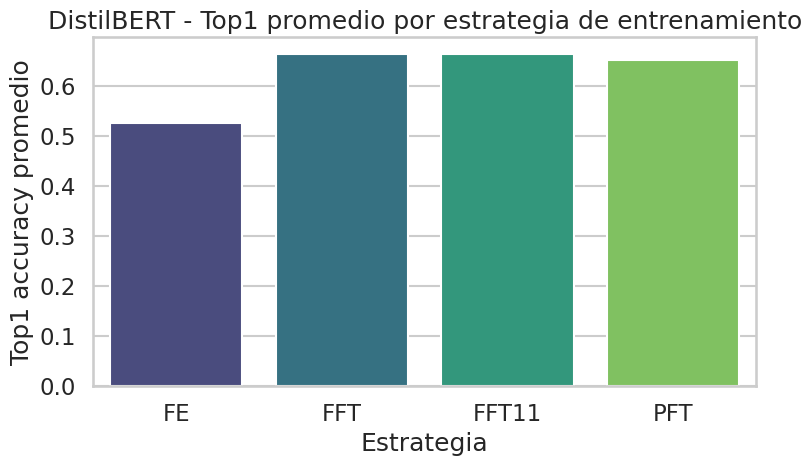

In [13]:

dist_top1 = dist_metrics.groupby('train_type')['top_1_acc'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=dist_top1, x='train_type', y='top_1_acc', palette='viridis')
plt.title('DistilBERT - Top1 promedio por estrategia de entrenamiento')
plt.xlabel('Estrategia')
plt.ylabel('Top1 accuracy promedio')
plt.tight_layout()
plt.show()


## 6) Mejores baselines vs mejor DistilBERT

In [14]:

best_baseline = (
    baseline_long.groupby(['model','text_type'])[['top_1_acc','top_2_acc','top_3_acc','top_4_acc','top_5_acc']]
    .mean()
    .reset_index()
    .assign(source='Baseline')
    .sort_values('top_1_acc', ascending=False)
    .head(1)
)

best_distilbert = (
    dist_metrics.groupby('train_type')[['top_1_acc','top_2_acc','top_3_acc','top_4_acc','top_5_acc']]
    .mean()
    .reset_index()
    .rename(columns={'train_type':'variant'})
    .assign(source='DistilBERT')
    .sort_values('top_1_acc', ascending=False)
    .head(1)
)

best_baseline['variant'] = best_baseline['model'] + '_' + best_baseline['text_type']
best_baseline = best_baseline[['source','variant','top_1_acc','top_2_acc','top_3_acc','top_4_acc','top_5_acc']]
best_distilbert = best_distilbert[['source','variant','top_1_acc','top_2_acc','top_3_acc','top_4_acc','top_5_acc']]

best_vs_best = pd.concat([best_baseline,best_distilbert], ignore_index=True)
best_vs_best


,source,variant,top_1_acc,top_2_acc,top_3_acc,top_4_acc,top_5_acc
0,Baseline,D2V_PREPRO+NGRAM,0.608432,0.684756,0.714870,0.731481,0.743080
1,DistilBERT,FFT11,0.663724,0.755307,0.797565,0.822182,0.838823


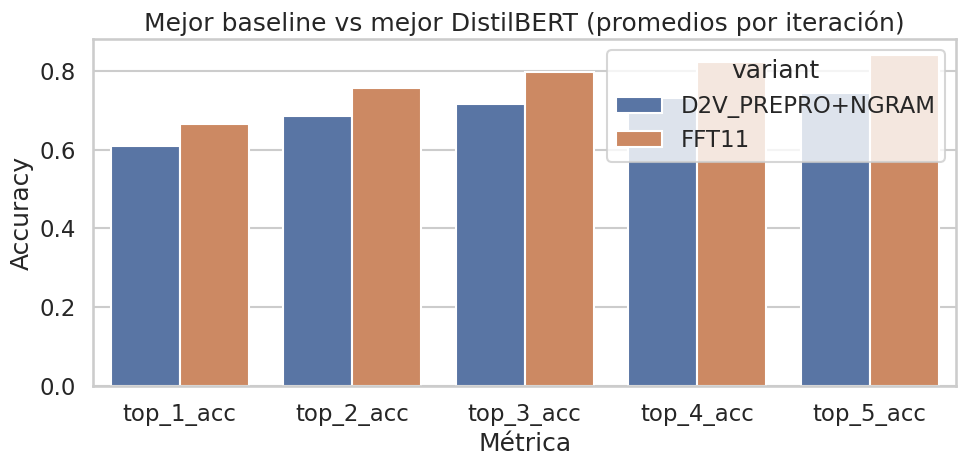

In [15]:

plot = best_vs_best.melt(id_vars=['source','variant'], value_vars=['top_1_acc','top_2_acc','top_3_acc','top_4_acc','top_5_acc'], var_name='metric', value_name='acc')
plt.figure(figsize=(10,5))
sns.barplot(data=plot, x='metric', y='acc', hue='variant')
plt.title('Mejor baseline vs mejor DistilBERT (promedios por iteración)')
plt.xlabel('Métrica')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


## 7) Exportables tabulares

Estas tablas dejan material listo para anexar al informe en Markdown.

In [16]:

out_analytics = Path('results') / 'iterative_analysis'
out_analytics.mkdir(parents=True, exist_ok=True)

baseline_summary.to_csv(out_analytics / 'baseline_summary_stats.csv')
dist_summary.to_csv(out_analytics / 'distilbert_summary_stats.csv')
best_epochs.to_csv(out_analytics / 'distilbert_best_epochs_by_iteration.csv', index=False)
best_vs_best.to_csv(out_analytics / 'best_baseline_vs_best_distilbert.csv', index=False)

print('Exportado en:', out_analytics)


Exportado en: results/iterative_analysis
